In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt
import scipy

In [11]:
from urllib.request import urlretrieve
filename = '../solutions/dr7qso.dat'
if not os.path.exists(filename):
   urlretrieve("https://das.sdss.org/va/qsocat/dr7qso.dat", filename)


Text(0.5, 0, 'z')

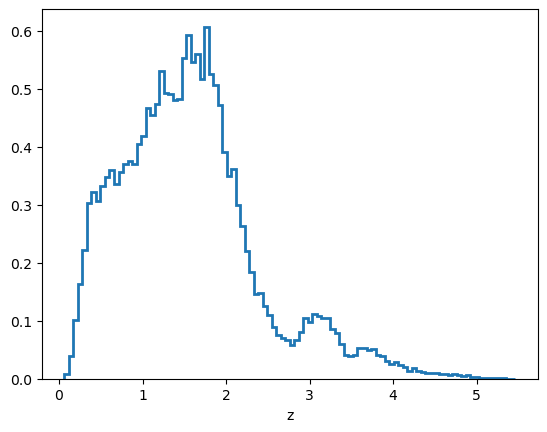

In [12]:
z= np.loadtxt(filename,skiprows=80, usecols=3)
nums, lims, fig  = plt.hist(z,bins=100,density=True,histtype='step',lw=2)
plt.xlabel('z')

In [ ]:
# Upsample this distribution in two ways
# rejection sampling

N = 100000
z_up = []


for _ in range(N):
    x = np.random.uniform(lims[0], lims[-1])
    y = np.random.uniform(nums.min(), nums.max())
    idx = np.min(np.where(lims > x))-1 
    if y < nums[idx]:
        z_up.append(x)


Text(0.5, 1.0, 'Rejection sampling')

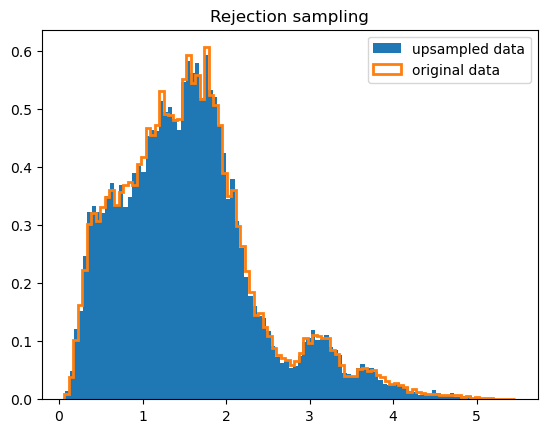

In [14]:
_ = plt.hist(z_up, bins = 100, density = True, label = 'upsampled data')
_ = plt.hist(z,bins=100,density=True,histtype='step',lw=2, label = 'original data')
plt.legend()
plt.title('Rejection sampling')

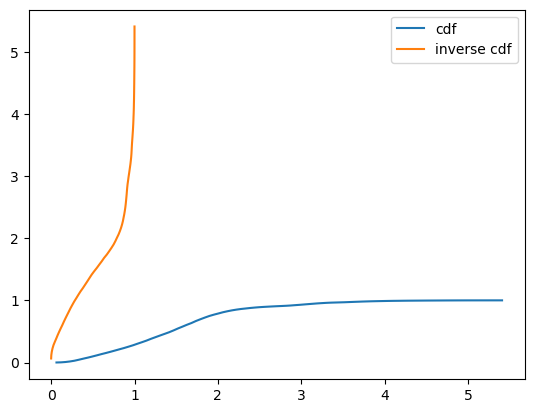

In [23]:
# inverse transform: u from uniform pdf + cdf H -> quantile H^-1 -> value of x below which a fraction u is contained
# x is sampled from h!
N = 100000
z_up_inv = []

cdf = np.cumsum(nums)*np.diff(lims)[0]
plt.plot(lims[:-1], cdf, label = 'cdf')
plt.plot(cdf, lims[:-1], label = 'inverse cdf')
plt.legend()

In [32]:
quant = scipy.interpolate.interp1d(cdf, lims[:-1], fill_value="extrapolate")
u = np.random.uniform(0,1,N)
z_up_inv = quant(u)

Text(0.5, 1.0, 'Inverse sampling')

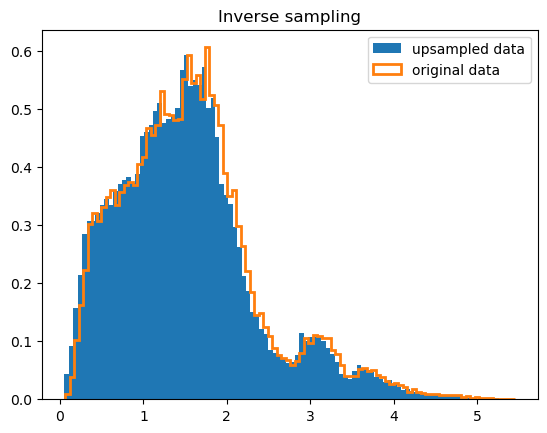

In [33]:
_ = plt.hist(z_up_inv, bins = 100, density = True, label = 'upsampled data')
_ = plt.hist(z,bins=100,density=True,histtype='step',lw=2, label = 'original data')
plt.legend()
plt.title('Inverse sampling')

Text(0.5, 1.0, 'Upsampling')

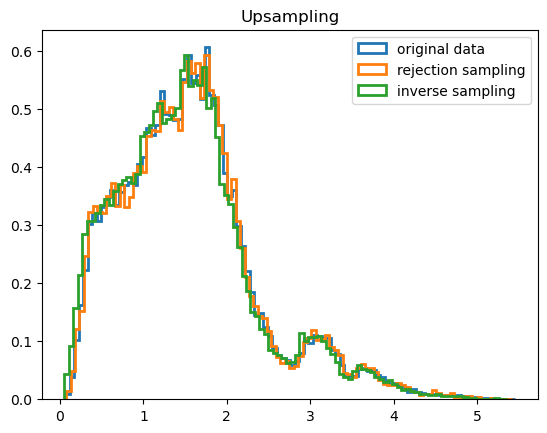

In [36]:
_ = plt.hist(z,bins=100,density=True,histtype='step',lw=2, label = 'original data')
_ = plt.hist(z_up, bins = 100, density = True, histtype='step',lw=2, label = 'rejection sampling')
_ = plt.hist(z_up_inv, bins = 100, density = True, histtype='step',lw=2, label = 'inverse sampling')
plt.legend()
plt.title('Upsampling')

In [18]:
# (for a quantitative check, come back to this point in a few lectures)


In [19]:
#Think about the cosmology of quasars. How do you think they are distributed? 
# Overplot the theorethical distribution to the measured SDSS data. Does that agree with your expectation?
#(Hint: It shouldn't. But why?)